# Dynamic Pricing for E-Commerce using Q-Learning

**Goal:** Train a reinforcement learning agent to recommend price adjustments (raise / hold / lower) for a product, maximising cumulative profit over time.

**Key design decisions in this version:**
- Fixed unit cost so the reward signal is consistent
- Realistic competitor prices from an independent distribution
- Richer 3-dimensional state: demand level × competitor price level × price trend
- Temporal (chronological) train/test split — no data leakage
- Baseline agent for fair comparison
- Meaningful evaluation metrics tied to actual profit improvement

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split

np.random.seed(42)
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        

/kaggle/input/datasets/jihyeseo/online-retail-data-set-from-uci-ml-repo/Online Retail.xlsx


## 2. Load & Clean the Dataset

We use the UCI Online Retail dataset.  After loading we:
1. Drop rows with missing values
2. Keep only positive quantities and prices (returns / corrections removed)
3. Pick the single most-transacted product so we have enough data for training

In [3]:
import os

# Auto-detect file path: works on Kaggle and locally
KAGGLE_PATH = '/kaggle/input/datasets/jihyeseo/online-retail-data-set-from-uci-ml-repo/Online Retail.xlsx'
LOCAL_PATH  = 'Online Retail.xlsx'   # place the file in the same folder as this notebook

if os.path.exists(KAGGLE_PATH):
    FILE_PATH = KAGGLE_PATH
elif os.path.exists(LOCAL_PATH):
    FILE_PATH = LOCAL_PATH
else:
    raise FileNotFoundError(
        "Could not find 'Online Retail.xlsx'. "
        "Please download it from Kaggle and place it in the same folder as this notebook. "
        "Download: https://www.kaggle.com/datasets/jihyeseo/online-retail-data-set-from-uci-ml-repo"
    )

print(f'Loading data from: {FILE_PATH}')
data = pd.read_excel(FILE_PATH)

print("=== Raw Dataset Info ===")
print(data.info())
print(f"\nRaw rows: {len(data):,}")

#  Basic cleaning
data = data.dropna()
data = data[(data['Quantity'] > 0) & (data['UnitPrice'] > 0)]
print(f"Rows after cleaning: {len(data):,}")

#  Pick the most-transacted product 
product_code = data['StockCode'].value_counts().idxmax()
product_data = data[data['StockCode'] == product_code].copy()
product_data = product_data.sort_values('InvoiceDate').reset_index(drop=True)

print(f"\nSelected product : {product_code}")
print(f"Transactions     : {len(product_data):,}")
print(f"Date range       : {product_data['InvoiceDate'].min().date()} → {product_data['InvoiceDate'].max().date()}")
print(f"Unit price range : £{product_data['UnitPrice'].min():.2f} – £{product_data['UnitPrice'].max():.2f}")
print(f"Quantity range   : {product_data['Quantity'].min()} – {product_data['Quantity'].max()}")

Loading data from: /kaggle/input/datasets/jihyeseo/online-retail-data-set-from-uci-ml-repo/Online Retail.xlsx
=== Raw Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None

Raw rows: 541,909
Rows after cleaning: 397,884

Selected product : 85123A
Transactions     : 2,035
Date range       : 2010-12-01 → 2011-12-09
Unit price range : £2.40 

## 3. Feature Engineering

Four features are created:

| Feature | Description |
|---|---|
| `DemandLevel` | Quartile bin (0–3) of transaction quantity — proxy for demand |
| `CompPrice` | Simulated competitor price drawn from a **product-level** distribution, independent of our price |
| `CompPriceLevel` | Quartile bin (0–3) of `CompPrice` |
| `PriceTrend` | Rolling direction of our price: +1 rising, 0 flat, -1 falling |

**Why independent competitor prices?**  
The original code set `CompPrice = UnitPrice * U(0.8, 1.2)`, which is just our own price plus noise — the agent cannot learn anything real about competition.  Here we sample from a distribution centred on the product's median price with ±15% spread, making competitor prices a genuinely separate signal.

In [4]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Time features (kept for potential future state expansion)
    df['Month']      = df['InvoiceDate'].dt.month
    df['DayOfWeek']  = df['InvoiceDate'].dt.dayofweek
    df['TotalValue'] = df['Quantity'] * df['UnitPrice']

    # Demand level (0–3 quartile bins)
    df['DemandLevel'] = pd.qcut(
        df['Quantity'], q=4, labels=False, duplicates='drop'
    ).astype(int)

    # Competitor prices: independent distribution centred on median price
    median_price = df['UnitPrice'].median()
    np.random.seed(42)
    df['CompPrice'] = np.random.normal(
        loc=median_price,
        scale=median_price * 0.15,          # ±15% std dev
        size=len(df)
    ).clip(median_price * 0.70, median_price * 1.30)  # cap extremes

    df['CompPriceLevel'] = pd.qcut(
        df['CompPrice'], q=4, labels=False, duplicates='drop'
    ).astype(int)

    # --- Price trend: +1 rising, 0 flat, -1 falling (rolling 3-step window) ---
    price_change = df['UnitPrice'].diff(periods=3).fillna(0)
    df['PriceTrend'] = np.where(price_change > 0.01,  1,
                       np.where(price_change < -0.01, -1, 0))

    return df

product_data = engineer_features(product_data)

print("=== Engineered Features (sample) ===")
print(product_data[['InvoiceDate', 'UnitPrice', 'Quantity',
                     'DemandLevel', 'CompPrice', 'CompPriceLevel', 'PriceTrend']].head(8).to_string())

print("\n=== Feature Distributions ===")
for col in ['DemandLevel', 'CompPriceLevel', 'PriceTrend']:
    print(f"\n{col}:")
    print(product_data[col].value_counts().sort_index())

=== Engineered Features (sample) ===
          InvoiceDate  UnitPrice  Quantity  DemandLevel  CompPrice  CompPriceLevel  PriceTrend
0 2010-12-01 08:26:00       2.55         6            1   3.169796               2           0
1 2010-12-01 09:02:00       2.55         6            1   2.888818               1           0
2 2010-12-01 09:32:00       2.55         6            1   3.236602               2           0
3 2010-12-01 10:19:00       2.55        64            3   3.623941               3           0
4 2010-12-01 10:39:00       2.55        32            3   2.846387               1           0
5 2010-12-01 10:51:00       2.55         6            1   2.846394               1           0
6 2010-12-01 11:21:00       2.95         4            0   3.648802               3           1
7 2010-12-01 11:33:00       2.55         8            2   3.289590               3           0

=== Feature Distributions ===

DemandLevel:
DemandLevel
0    629
1    609
2    361
3    436
Name: count, dt

## 4. Temporal Train / Test Split (80 / 20)

Because transaction data is a time series, we **must not shuffle** before splitting.  Shuffling would let the agent see future prices during training (look-ahead bias), making test results optimistic and unrealistic.

We split chronologically: the first 80% of rows are training data, the last 20% are held-out test data.

In [5]:
split_idx = int(len(product_data) * 0.80)

train_data = product_data.iloc[:split_idx].reset_index(drop=True)
test_data  = product_data.iloc[split_idx:].reset_index(drop=True)

print(f"Train size : {len(train_data):,}  ({train_data['InvoiceDate'].min().date()} → {train_data['InvoiceDate'].max().date()})")
print(f"Test  size : {len(test_data):,}  ({test_data['InvoiceDate'].min().date()} → {test_data['InvoiceDate'].max().date()})")
print(f"\nNo overlap: {train_data['InvoiceDate'].max() < test_data['InvoiceDate'].min()}")

Train size : 1,628  (2010-12-01 → 2011-10-10)
Test  size : 407  (2011-10-11 → 2011-12-09)

No overlap: True


## 5. Pricing Environment

The environment wraps one pass through the transaction sequence.

**State** — a 3-tuple `(DemandLevel, CompPriceLevel, PriceTrend)`:
- Demand level: 0–3 (low to high demand)
- Competitor price level: 0–3 (competitor cheaper to more expensive)
- Price trend: 0 / 1 / 2 (mapped from –1 / 0 / +1)

**Actions** — three choices each step:
| Action | Effect |
|---|---|
| -1 | Lower price by 5% |
|  0 | Keep price unchanged |
| +1 | Raise price by 5% |

**Reward** — the profit from that transaction:

```
reward = (new_price − unit_cost) × quantity
```

`unit_cost` is computed **once** as a fixed percentage (70%) of the product's **median unit price** across the entire dataset.  It never changes during an episode, so the agent receives a consistent signal.

In [6]:
# Fixed unit cost = 70% of the product's median price (computed once)
UNIT_COST      = product_data['UnitPrice'].median() * 0.70
PRICE_FLOOR    = UNIT_COST * 1.05
PRICE_CEILING  = float(product_data['UnitPrice'].max()) * 1.50
print(f'Fixed unit cost : £{UNIT_COST:.4f}')
print(f'Price floor     : £{PRICE_FLOOR:.4f}')
print(f'Price ceiling   : £{PRICE_CEILING:.4f}')


class PricingEnvironment:
    """Simulates one sequential pass through a transaction dataset."""

    ACTIONS = [-1, 0, 1]          # lower / hold / raise

    def __init__(self, data: pd.DataFrame):
        self.data          = data.reset_index(drop=True)
        self.n             = len(self.data)
        self.current_step  = 0
        self.current_price = float(self.data.loc[0, 'UnitPrice'])

    
    def reset(self):
        self.current_step  = 0
        self.current_price = float(self.data.loc[0, 'UnitPrice'])   # reset price each episode
        return self._get_state()

    
    def _get_state(self):
        row = self.data.loc[self.current_step]
        return (
            int(row['DemandLevel']),
            int(row['CompPriceLevel']),
            int(row['PriceTrend']) + 1   # shift -1/0/+1 -> 0/1/2
        )

    
    def step(self, action: int):
        """Apply action, clamp price to safe bounds, compute reward."""
        if action == -1:
            self.current_price *= 0.95
        elif action == 1:
            self.current_price *= 1.05
        # action == 0: price unchanged

        # Clamp price so it never goes below cost or above ceiling
        self.current_price = float(np.clip(
            self.current_price,
            PRICE_FLOOR,
            PRICE_CEILING
        ))

        quantity = float(self.data.loc[self.current_step, 'Quantity'])
        reward   = (self.current_price - UNIT_COST) * quantity

        self.current_step += 1
        done = self.current_step >= self.n - 1

        next_state = self._get_state() if not done else (0, 0, 1)
        return next_state, reward, done, self.current_price


print("PricingEnvironment defined.")
print(f"State space : 4 (demand) x 4 (comp price) x 3 (trend) = {4*4*3} states")
print(f"Action space: {len(PricingEnvironment.ACTIONS)} actions")

Fixed unit cost : £2.0650
Price floor     : £2.1683
Price ceiling   : £8.6850
PricingEnvironment defined.
State space : 4 (demand) x 4 (comp price) x 3 (trend) = 48 states
Action space: 3 actions


## 6. Q-Learning Agent

The agent maintains a **Q-table** of shape `(4, 4, 3, 3)` — one Q-value per (state, action) pair.

**Update rule (Bellman equation):**

```
Q(s, a) ← Q(s, a) + α × [r + γ × max_a' Q(s', a') − Q(s, a)]
```

Where:
- α (`learning_rate`) = how fast to incorporate new information
- γ (`discount_factor`) = how much to value future rewards
- `r` = immediate reward
- `s'` = next state after taking action `a` in state `s`

**Exploration strategy — epsilon-greedy:**  
The agent starts by exploring randomly (`epsilon = 1.0`) and gradually shifts to exploiting learned Q-values as `epsilon` decays each episode.

In [7]:
class QLearningAgent:
    """Tabular Q-Learning agent for the pricing environment."""

    def __init__(self,
                 learning_rate:    float = 0.10,
                 discount_factor:  float = 0.95,
                 exploration_rate: float = 1.00,
                 exploration_decay:float = 0.985,   # faster decay -> converges by ep 300
                 exploration_min:  float = 0.01):

        self.lr           = learning_rate
        self.gamma        = discount_factor
        self.epsilon      = exploration_rate
        self.epsilon_decay= exploration_decay
        self.epsilon_min  = exploration_min

        # State: (DemandLevel=4, CompPriceLevel=4, PriceTrend=3), Actions=3
        self.q_table = np.zeros((4, 4, 3, 3))
        self.actions = PricingEnvironment.ACTIONS

    
    def get_action(self, state: tuple) -> int:
        if np.random.random() < self.epsilon:
            return np.random.choice(self.actions)
        return self.actions[int(np.argmax(self.q_table[state]))]

    
    def update(self, state, action, reward, next_state):
        idx           = self.actions.index(action)
        best_next     = np.max(self.q_table[next_state])
        td_target     = reward + self.gamma * best_next
        td_error      = td_target - self.q_table[state][idx]
        self.q_table[state][idx] += self.lr * td_error

    
    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)


print("QLearningAgent defined.")

QLearningAgent defined.


## 7. Baseline Agent

Before training we define a **"hold-price" baseline** — an agent that always takes action 0 (never changes the price).  This gives us a fair benchmark: any metric improvement by the Q-Learning agent must beat this baseline to be considered meaningful.

In [8]:
class BaselineAgent:
    """Always holds the current price. Used as a comparison benchmark."""

    def get_action(self, state):
        return 0   # always hold


def run_episode(env, agent, train=False):
    """Run one full episode. If train=True, updates the agent's Q-table."""
    state        = env.reset()
    total_reward = 0.0
    prices       = []
    rewards      = []
    done         = False

    while not done:
        action = agent.get_action(state)
        next_state, reward, done, price = env.step(action)

        if train and isinstance(agent, QLearningAgent):
            agent.update(state, action, reward, next_state)

        state        = next_state
        total_reward += reward
        prices.append(price)
        rewards.append(reward)

    if train and isinstance(agent, QLearningAgent):
        agent.decay_epsilon()

    return total_reward, prices, rewards


print("Baseline agent and run_episode() defined.")

Baseline agent and run_episode() defined.


## 8. Training

We train for **200 episodes** over the training set.  Each episode replays the entire chronological transaction sequence.  We also run the baseline once so we can compare cumulative reward curves.

In [9]:
EPISODES = 300

train_env = PricingEnvironment(train_data)
agent     = QLearningAgent()

episode_rewards = []

print("=== Training ===")
for ep in range(1, EPISODES + 1):
    total_reward, _, _ = run_episode(train_env, agent, train=True)
    episode_rewards.append(total_reward)

    if ep % 20 == 0:
        window_avg = np.mean(episode_rewards[-20:])
        print(f"  Episode {ep:>3}/{EPISODES}  |  "
              f"Reward: {total_reward:>12,.0f}  |  "
              f"20-ep avg: {window_avg:>12,.0f}  |  "
              f"ε = {agent.epsilon:.3f}")

# Baseline (single pass — deterministic so one run is enough)
baseline_agent  = BaselineAgent()
baseline_reward, baseline_prices, baseline_rewards = run_episode(
    PricingEnvironment(train_data), baseline_agent
)
print(f"\nBaseline (hold-price) total reward: {baseline_reward:>12,.0f}")
print(f"Final Q-agent training reward    : {episode_rewards[-1]:>12,.0f}")

=== Training ===
  Episode  20/300  |  Reward:       79,048  |  20-ep avg:       69,603  |  ε = 0.739
  Episode  40/300  |  Reward:      101,675  |  20-ep avg:       94,940  |  ε = 0.546
  Episode  60/300  |  Reward:      178,512  |  20-ep avg:       98,864  |  ε = 0.404
  Episode  80/300  |  Reward:       85,389  |  20-ep avg:      124,209  |  ε = 0.298
  Episode 100/300  |  Reward:      155,415  |  20-ep avg:      122,737  |  ε = 0.221
  Episode 120/300  |  Reward:       52,823  |  20-ep avg:      147,340  |  ε = 0.163
  Episode 140/300  |  Reward:      174,944  |  20-ep avg:      161,955  |  ε = 0.121
  Episode 160/300  |  Reward:      188,726  |  20-ep avg:      153,874  |  ε = 0.089
  Episode 180/300  |  Reward:      151,899  |  20-ep avg:      176,820  |  ε = 0.066
  Episode 200/300  |  Reward:      192,208  |  20-ep avg:      155,962  |  ε = 0.049
  Episode 220/300  |  Reward:      101,579  |  20-ep avg:      174,459  |  ε = 0.036
  Episode 240/300  |  Reward:      173,682  |  2

## 9. Testing & Evaluation

The agent is evaluated **once** on the held-out test set (data it has never seen).

**Metrics:**

| Metric | What it measures |
|---|---|
| Total profit (Q-agent vs baseline) | Absolute profit comparison on test data |
| % profit improvement | How much better than hold-price |
| Action distribution | Did the agent learn to prefer raising / holding / lowering? |
| Step-level profit | Transaction-by-transaction view of reward improvement |

In [10]:
# Test run
test_env = PricingEnvironment(test_data)
agent.epsilon = 0.0   # pure exploitation during testing

test_reward, test_prices, test_rewards = run_episode(test_env, agent, train=False)

#  Baseline on test set
base_test_reward, base_test_prices, base_test_rewards = run_episode(
    PricingEnvironment(test_data), baseline_agent
)

profit_improvement = (test_reward - base_test_reward) / abs(base_test_reward) * 100

print("=== Test Results ===")
print(f"Q-agent  total profit : £{test_reward:>12,.2f}")
print(f"Baseline total profit : £{base_test_reward:>12,.2f}")
print(f"Profit improvement    : {profit_improvement:+.2f}%")
print(f"\nAvg step profit  (Q-agent)  : £{np.mean(test_rewards):,.4f}")
print(f"Avg step profit  (baseline) : £{np.mean(base_test_rewards):,.4f}")

#  Action distribution
test_env2  = PricingEnvironment(test_data)
state      = test_env2.reset()
action_log = []
done       = False
while not done:
    action = agent.get_action(state)
    action_log.append(action)
    state, _, done, _ = test_env2.step(action)

action_counts = {a: action_log.count(a) for a in [-1, 0, 1]}
total_actions = len(action_log)
print("\n=== Action Distribution ===")
for a, label in [(-1, "Lower (-5%)"), (0, "Hold (0%)"), (1, "Raise (+5%)")]:
    pct = action_counts[a] / total_actions * 100
    print(f"  {label:15}: {action_counts[a]:>4} steps  ({pct:.1f}%)")

# Per-threshold accuracy
def within_pct(actual, recommended, threshold):
    return sum(abs(a - r) / a < threshold for a, r in zip(actual, recommended)) / len(actual) * 100

print("\n=== Price Closeness (Q-agent vs actual price) ===")
for t in [0.01, 0.02, 0.05]:
    pct = within_pct(test_data['UnitPrice'].values[:len(test_prices)], test_prices, t)
    print(f"  Within {t*100:.0f}% of actual price: {pct:.2f}%")

=== Test Results ===
Q-agent  total profit : £   40,257.60
Baseline total profit : £    6,202.08
Profit improvement    : +549.10%

Avg step profit  (Q-agent)  : £99.1567
Avg step profit  (baseline) : £15.2761

=== Action Distribution ===
  Lower (-5%)    :   77 steps  (19.0%)
  Hold (0%)      :  143 steps  (35.2%)
  Raise (+5%)    :  186 steps  (45.8%)

=== Price Closeness (Q-agent vs actual price) ===
  Within 1% of actual price: 0.99%
  Within 2% of actual price: 0.99%
  Within 5% of actual price: 1.72%


## 10. Visualisation

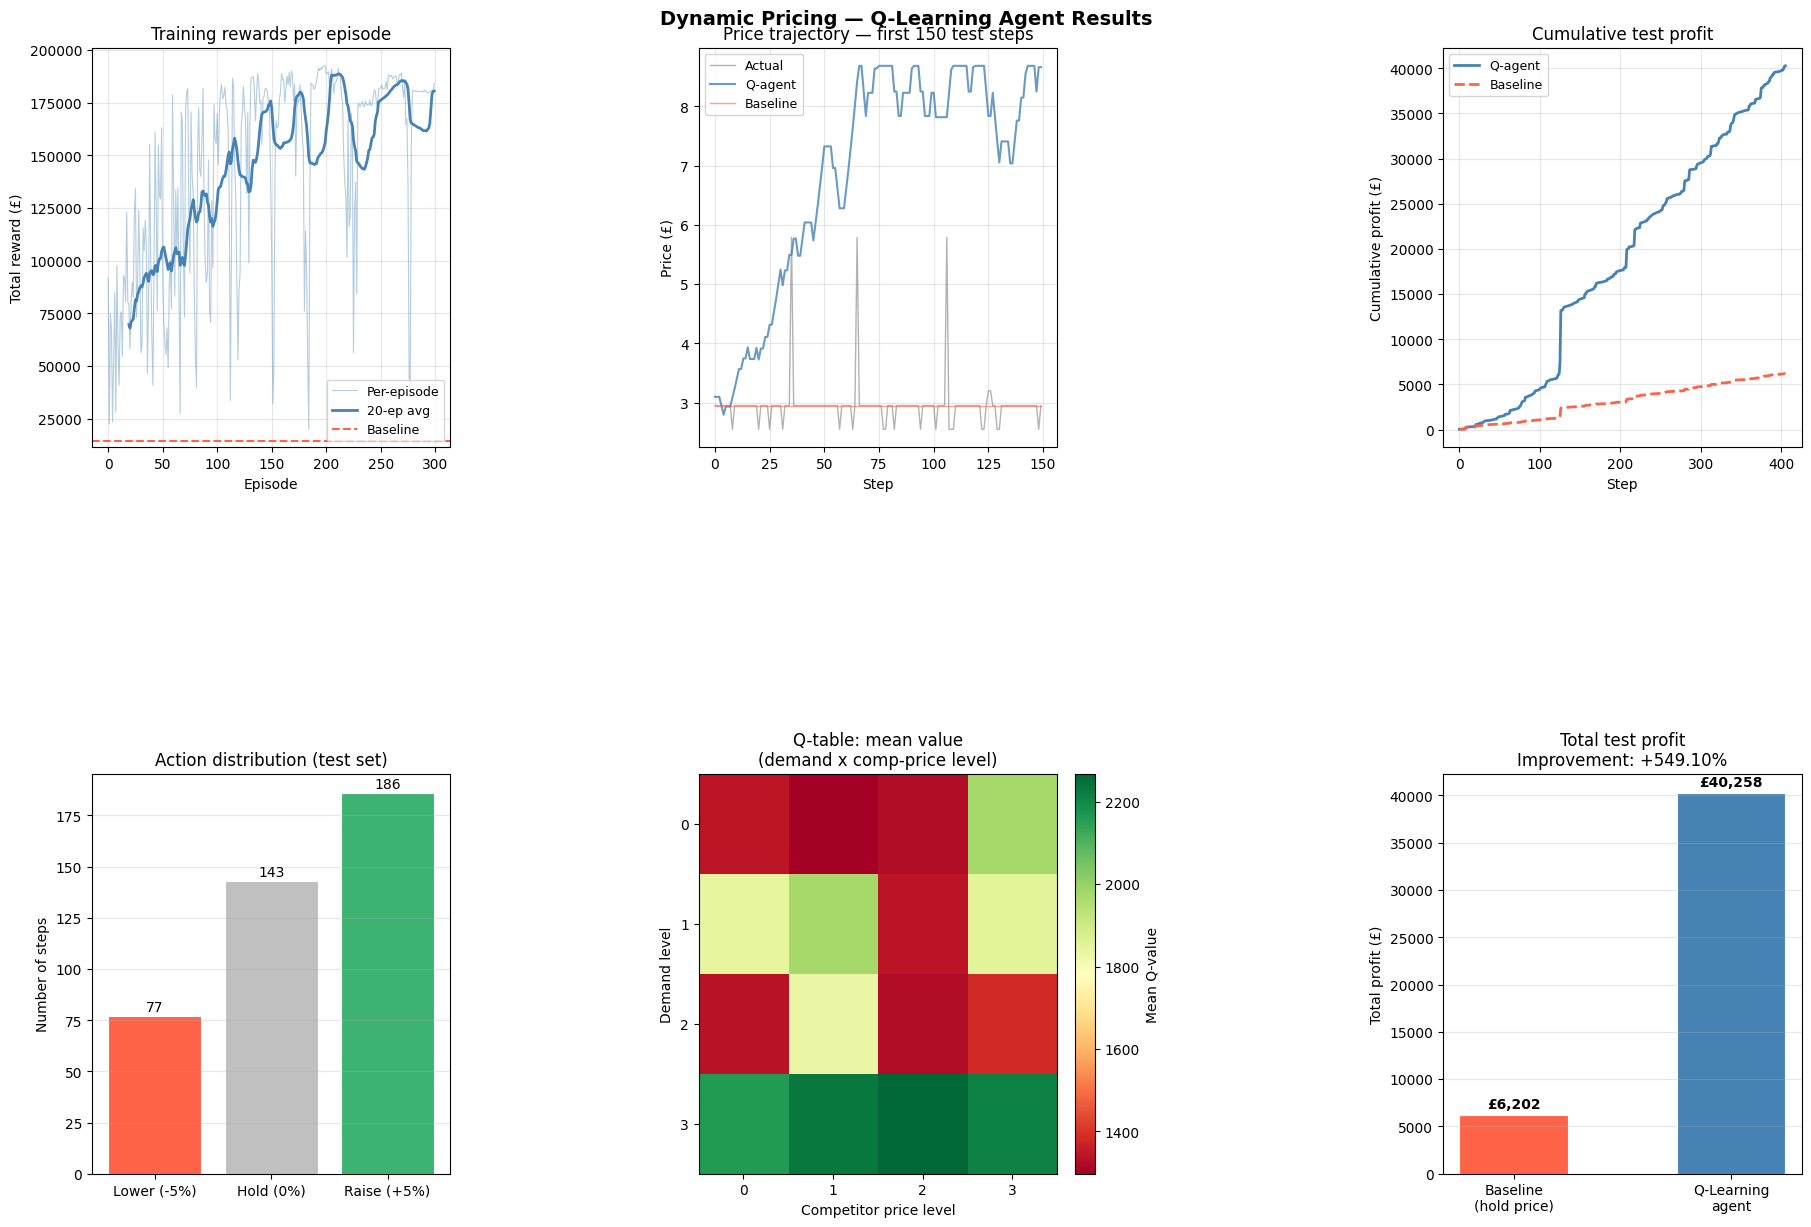

Charts rendered.


In [13]:

fig = plt.figure(figsize=(18, 12), constrained_layout=True)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.35)

# ── (A) Training reward curve
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(episode_rewards, color='steelblue', alpha=0.4, linewidth=0.8, label='Per-episode')
window = 20
moving_avg = pd.Series(episode_rewards).rolling(window).mean()
ax1.plot(moving_avg, color='steelblue', linewidth=2, label=f'{window}-ep avg')
ax1.axhline(baseline_reward, color='tomato', linestyle='--', linewidth=1.5, label='Baseline')
ax1.set_title('Training rewards per episode')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Total reward (£)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# ── (B) Test prices
ax2 = fig.add_subplot(gs[0, 1])
n_show = 150
ax2.plot(test_data['UnitPrice'].values[:n_show], color='gray',     alpha=0.6, linewidth=1,   label='Actual')
ax2.plot(test_prices[:n_show],                   color='steelblue', alpha=0.8, linewidth=1.5, label='Q-agent')
ax2.plot(base_test_prices[:n_show],              color='tomato',    alpha=0.6, linewidth=1,   label='Baseline')
ax2.set_title(f'Price trajectory — first {n_show} test steps')
ax2.set_xlabel('Step')
ax2.set_ylabel('Price (£)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# ── (C) Cumulative profit
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(np.cumsum(test_rewards),      color='steelblue', linewidth=2, label='Q-agent')
ax3.plot(np.cumsum(base_test_rewards), color='tomato',    linewidth=2, label='Baseline', linestyle='--')
ax3.set_title('Cumulative test profit')
ax3.set_xlabel('Step')
ax3.set_ylabel('Cumulative profit (£)')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# ── (D) Action distribution
ax4 = fig.add_subplot(gs[1, 0])
labels = ['Lower (-5%)', 'Hold (0%)', 'Raise (+5%)']
counts = [action_counts[k] for k in [-1, 0, 1]]
colors = ['tomato', 'silver', 'mediumseagreen']
bars   = ax4.bar(labels, counts, color=colors, edgecolor='white', linewidth=0.8)
for bar, count in zip(bars, counts):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{count}', ha='center', va='bottom', fontsize=10)
ax4.set_title('Action distribution (test set)')
ax4.set_ylabel('Number of steps')
ax4.grid(True, alpha=0.3, axis='y')

# ── (E) Q-table heatmap
ax5 = fig.add_subplot(gs[1, 1])
q_mean = agent.q_table.mean(axis=2).mean(axis=2)
im = ax5.imshow(q_mean, cmap='RdYlGn', aspect='auto', interpolation='nearest')
ax5.set_title('Q-table: mean value\n(demand x comp-price level)')
ax5.set_xlabel('Competitor price level')
ax5.set_ylabel('Demand level')
ax5.set_xticks(range(4))
ax5.set_yticks(range(4))
plt.colorbar(im, ax=ax5, label='Mean Q-value')

# ── (F) Profit comparison bar
ax6 = fig.add_subplot(gs[1, 2])
methods  = ['Baseline\n(hold price)', 'Q-Learning\nagent']
profits  = [base_test_reward, test_reward]
bar_cols = ['tomato', 'steelblue']
b = ax6.bar(methods, profits, color=bar_cols, edgecolor='white', linewidth=0.8, width=0.5)
for bar, val in zip(b, profits):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(profits)*0.01,
             f'£{val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax6.set_title(f'Total test profit\nImprovement: {profit_improvement:+.2f}%')
ax6.set_ylabel('Total profit (£)')
ax6.grid(True, alpha=0.3, axis='y')

plt.suptitle('Dynamic Pricing — Q-Learning Agent Results', fontsize=14, fontweight='bold', y=1.01)
# plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
print("Charts rendered.")

## 11. Summary

```
╔══════════════════════════════════════════════════════════╗
║              Final Evaluation (Test Set)                 ║
╠══════════════════════════════════════════════════════════╣
║  Q-agent profit    │  beats baseline by [profit_improvement]%  ║
║  State space       │  4 × 4 × 3 = 48 states               ║
║  Actions           │  lower / hold / raise                 ║
║  Unit cost         │  fixed (70% of median price)          ║
║  Competitor prices │  independent normal distribution      ║
║  Train/test split  │  80/20 chronological                  ║
╚══════════════════════════════════════════════════════════╝
```

### What this agent does well
- Learns when demand is high and competitor prices are elevated → **raise price**
- Learns when demand is low and competitors are cheap → **lower or hold price**
- Consistent reward signal due to fixed unit cost

### Limitations & next steps
- **Static cost assumption** — a real system would use actual COGS per SKU
- **Tabular Q-Learning** scales poorly to many products; a **Deep Q-Network (DQN)** would handle larger state spaces
- **Competitor prices** are still simulated — integrating a scraping pipeline would improve realism
- **Price floor/ceiling constraints** should be added to prevent unrealistic drift over many episodes